<a href="https://colab.research.google.com/github/mythogenesys/Andrew-NG-DL-practises/blob/main/verifierVeGIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==============================================================================
# Step 1: Setup and Configuration
# ==============================================================================
# Install any necessary libraries (not needed for this setup in default Colab)
# !pip install torch numpy matplotlib tqdm

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import random
import operator
import copy

# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Configuration Object ---
class Config:
    # Task Configuration
    NUM_STEPS = 3  # e.g., (a+b)*c -> d*c -> e
    OPERATORS = {'+': operator.add, '-': operator.sub, '*': operator.mul}

    # Model Configuration
    INPUT_DIM = 20  # Vocab size: 0-9, (), +-*/, space, SOS, EOS
    OUTPUT_DIM = 20
    EMBED_DIM = 64
    HIDDEN_DIM = 128
    NUM_LAYERS = 1
    MAX_LEN = 25 # Max length of a problem string

    # ESML (Evolutionary Algorithm) Configuration
    POPULATION_SIZE = 50
    NUM_GENERATIONS = 5
    ELITISM = 0.20  # Top 20% of policies survive unchanged
    TOURNAMENT_SIZE = 5
    MUTATION_PROB = 0.9 # Probability a non-elite member is mutated
    MUTATION_STRENGTH = 0.02 # Std dev of Gaussian noise added to weights

    # Evaluation Configuration
    EVAL_BATCH_SIZE = 16 # Number of problems to evaluate each policy on for E(theta)
    VALIDATION_SIZE = 20 # Number of fixed problems to check for monotonicity

# Instantiate config
config = Config()

# --- Vocabulary and Tokenizer ---
# Simple character-level tokenizer for our limited arithmetic language
vocab = "0123456789+-*()/ "
char_to_int = {char: i + 2 for i, char in enumerate(vocab)}
char_to_int['<SOS>'] = 0
char_to_int['<EOS>'] = 1
int_to_char = {i: char for char, i in char_to_int.items()}
config.INPUT_DIM = len(char_to_int)
config.OUTPUT_DIM = len(char_to_int)

def tokenize(s):
    return [char_to_int[c] for c in s]

def detokenize(t):
    return "".join([int_to_char[i] for i in t if i > 1]) # Exclude SOS/EOS

Using device: cuda


In [ ]:
# ==============================================================================
# Step 2: The Task Environment and the Verifier (E) - CORRECTED WITH TIMEOUT
# ==============================================================================
import signal

class ArithmeticTask:
    """Generates multi-step arithmetic problems and their solution traces."""
    def __init__(self, num_steps, operators):
        self.num_steps = num_steps
        self.operators = operators

    def generate_problem(self):
        """Generates a problem and its full solution trace."""
        nums = [random.randint(1, 9) for _ in range(self.num_steps + 1)]
        ops = [random.choice(list(self.operators.keys())) for _ in range(self.num_steps)]
        expression = f"({nums[0]} {ops[0]} {nums[1]})"
        for i in range(1, self.num_steps):
            expression = f"({expression} {ops[i]} {nums[i+1]})"
        trace = [expression]
        current_expr = expression
        while len(trace) <= self.num_steps:
            start = current_expr.rfind('(')
            end = current_expr.find(')', start)
            if start == -1 or end == -1: break # Stop if no more parens
            sub_expr = current_expr[start+1:end]
            try:
                result = eval(sub_expr)
                current_expr = current_expr[:start] + str(result) + current_expr[end+1:]
                trace.append(current_expr)
            except:
                return self.generate_problem() # Should be rare
        return trace

class TimeoutException(Exception):
    pass

class Verifier:
    """Implements the efficacy functional E, hardened against multiple failure modes."""

    def _timeout_handler(self, signum, frame):
        raise TimeoutException("Evaluation timed out")

    def evaluate(self, expression_str, timeout_seconds=1):
        """
        Calculates the ground truth value of an expression with a timeout.
        Returns (value, is_correct_syntax)
        """
        signal.signal(signal.SIGALRM, self._timeout_handler)
        signal.alarm(timeout_seconds)

        try:
            result = eval(expression_str)
            signal.alarm(0)
            return result, 1.0
        # *** THE FIX IS HERE ***
        # Add OverflowError to the list of caught exceptions.
        except (SyntaxError, ZeroDivisionError, NameError, TypeError, TimeoutException, OverflowError):
            signal.alarm(0)
            return 0, 0.0

    def get_stepwise_efficacy(self, generated_trace, ground_truth_trace):
        """
        Compares a generated trace to the ground truth, returning efficacy at each step.
        """
        efficacies = []
        for gen_step, true_step in zip(generated_trace, ground_truth_trace):
            gen_val, gen_syntax_ok = self.evaluate(gen_step)
            true_val, true_syntax_ok = self.evaluate(true_step)
            if gen_syntax_ok and true_syntax_ok and gen_val == true_val:
                efficacies.append(1.0)
            else:
                efficacies.append(0.0)
        return efficacies

# --- Instantiate and Test ---
task_generator = ArithmeticTask(config.NUM_STEPS, config.OPERATORS)
verifier = Verifier()

# Test the new fix
print("Testing the fix for OverflowError:")
# This expression will now be caught gracefully instead of crashing
print(f'eval("99**99") -> {verifier.evaluate("99**99")}')

Testing the fix for OverflowError:
eval("99**99") -> (369729637649726772657187905628805440595668764281741102430259972423552570455277523421410650010128232727940978889548326540119429996769494359451621570193644014418071060667659301384999779999159200499899, 1.0)


In [ ]:
# --- Quick Fix: Ensure Seq2Seq has get_full_trace() defined ---

class Seq2Seq(nn.Module):
    """A simple Encoder-Decoder network representing a policy."""
    def __init__(self, config):
        super().__init__()
        self.embedding = nn.Embedding(config.INPUT_DIM, config.EMBED_DIM)
        self.encoder = nn.GRU(config.EMBED_DIM, config.HIDDEN_DIM,
                              config.NUM_LAYERS, batch_first=True)
        self.decoder = nn.GRU(config.EMBED_DIM, config.HIDDEN_DIM,
                              config.NUM_LAYERS, batch_first=True)
        self.fc = nn.Linear(config.HIDDEN_DIM, config.OUTPUT_DIM)

    def generate_step(self, input_str):
        """Generates the next step in the reasoning trace from an input string."""
        self.eval()
        with torch.no_grad():
            # Tokenize safely
            tokens = tokenize(input_str)
            if len(tokens) == 0:  # safeguard against empty inputs
                tokens = [char_to_int['<SOS>'], char_to_int['<EOS>']]

            input_tensor = torch.LongTensor([tokens]).to(device)
            embedded = self.embedding(input_tensor)
            _, hidden = self.encoder(embedded)

            # Start decoding with <SOS> token
            decoder_input = torch.LongTensor([[char_to_int['<SOS>']]]).to(device)
            outputs = []
            for _ in range(config.MAX_LEN):
                embedded_dec = self.embedding(decoder_input)
                output, hidden = self.decoder(embedded_dec, hidden)
                prediction = self.fc(output)

                next_char_idx = prediction.argmax(2).item()
                if next_char_idx == char_to_int['<EOS>']:
                    break
                outputs.append(next_char_idx)
                decoder_input = torch.LongTensor([[next_char_idx]]).to(device)

            # If decoder produced nothing (empty output), fall back to the input string
            if len(outputs) == 0:
                return input_str
            return detokenize(outputs)


    @torch.no_grad()
    def get_full_trace(self, problem_str):
        """Generates a full reasoning trace for a given problem."""
        trace = [problem_str]
        current_expr = problem_str
        for _ in range(config.NUM_STEPS):
            next_expr = self.generate_step(current_expr)
            trace.append(next_expr)
            current_expr = next_expr
        return trace


In [ ]:
# ==============================================================================
# Step 4: The Efficacy-Seeking Meta-Learner (ESML)  (Corrected & Optimized)
# ==============================================================================

import gc

class ESML:
    def __init__(self, config, task_generator, verifier):
        self.config = config
        self.task_generator = task_generator
        self.verifier = verifier

        print("Initializing population...")
        self.population = [Seq2Seq(config).to(device) for _ in range(config.POPULATION_SIZE)]
        self.fitness = np.zeros(config.POPULATION_SIZE)

        # Fixed validation set for monotonicity check
        self.validation_set = [self.task_generator.generate_problem() for _ in range(config.VALIDATION_SIZE)]

    @torch.no_grad()
    def evaluate_population(self):
        """Compute fitness E(theta) for each policy."""
        torch.set_grad_enabled(False)
        for i, policy in enumerate(self.population):
            if i % 10 == 0:
                print(f"  Evaluating {i}/{len(self.population)}", end='\r')

            correct_final_answers = 0
            for _ in range(self.config.EVAL_BATCH_SIZE):
                gt_trace = self.task_generator.generate_problem()
                problem = gt_trace[0]
                final_gt_answer = self.verifier.evaluate(gt_trace[-1])[0]

                generated_trace = policy.get_full_trace(problem)
                final_gen_answer, syntax_ok = self.verifier.evaluate(generated_trace[-1])

                if syntax_ok and final_gen_answer == final_gt_answer:
                    correct_final_answers += 1

            self.fitness[i] = correct_final_answers / self.config.EVAL_BATCH_SIZE

        torch.cuda.empty_cache()

    def select(self):
        """Tournament selection respecting ESML monotonicity."""
        selected_parents = []
        for _ in range(self.config.POPULATION_SIZE):
            tournament = random.sample(range(self.config.POPULATION_SIZE), self.config.TOURNAMENT_SIZE)
            winner_idx = max(tournament, key=lambda idx: self.fitness[idx])
            selected_parents.append(self.population[winner_idx])
        return selected_parents

    @torch.no_grad()
    def mutate(self, policy):
        """Applies Gaussian mutation on CPU to avoid GPU memory leak."""
        policy_cpu = copy.deepcopy(policy).to('cpu')
        for param in policy_cpu.parameters():
            noise = torch.randn_like(param) * self.config.MUTATION_STRENGTH
            param.add_(noise)
        mutated = policy_cpu.to(device)
        del policy_cpu
        return mutated

    def run_generation(self):
        """Runs one full cycle of evaluation, selection, and variation."""
        print("\n--- Running Generation ---")
        self.evaluate_population()

        parents = self.select()
        new_population = []

        # Elitism
        num_elites = int(self.config.POPULATION_SIZE * self.config.ELITISM)
        elite_indices = np.argsort(self.fitness)[::-1][:num_elites]
        for idx in elite_indices:
            new_population.append(copy.deepcopy(self.population[idx]))

        # Mutation / reproduction
        for i in range(num_elites, self.config.POPULATION_SIZE):
            parent = parents[i]
            if random.random() < self.config.MUTATION_PROB:
                child = self.mutate(parent)
            else:
                child = copy.deepcopy(parent)
            new_population.append(child)

        self.population = new_population

        # Cleanup to prevent Colab hangs
        gc.collect()
        torch.cuda.empty_cache()

    @torch.no_grad()
    def check_monotonicity(self):
        """Fraction of perfectly monotonic policies in validation set."""
        torch.set_grad_enabled(False)
        monotonic_count = 0

        for policy in self.population:
            is_policy_fully_monotonic = True
            for gt_trace in self.validation_set:
                problem = gt_trace[0]
                generated_trace = policy.get_full_trace(problem)
                efficacies = self.verifier.get_stepwise_efficacy(generated_trace, gt_trace)

                if not all(e2 >= e1 for e1, e2 in zip(efficacies, efficacies[1:])):
                    is_policy_fully_monotonic = False
                    break

            if is_policy_fully_monotonic:
                monotonic_count += 1

        torch.cuda.empty_cache()
        return monotonic_count / self.config.POPULATION_SIZE


In [ ]:
# ==============================================================================
# Step 5: Main Loop and Visualization
# ==============================================================================

# --- Initialize the learner ---
esml_system = ESML(config, task_generator, verifier)

# --- Data Loggers ---
history = {
    'avg_fitness': [],
    'max_fitness': [],
    'monotonic_fraction': []
}

# --- Main Evolutionary Loop ---
print("Starting ESML evolution...")
for gen in range(config.NUM_GENERATIONS):
    esml_system.run_generation()

    # --- Log Metrics ---
    avg_fit = np.mean(esml_system.fitness)
    max_fit = np.max(esml_system.fitness)
    mono_frac = esml_system.check_monotonicity()

    history['avg_fitness'].append(avg_fit)
    history['max_fitness'].append(max_fit)
    history['monotonic_fraction'].append(mono_frac)

    print(f"Generation {gen+1}/{config.NUM_GENERATIONS} | "
          f"Avg Fitness: {avg_fit:.3f} | "
          f"Max Fitness: {max_fit:.3f} | "
          f"Monotonic Fraction: {mono_frac:.3f}")

print("\nEvolution complete.")


# --- Generate the Killer Figures ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
fig.suptitle('Verifier-Guided Iterative Reasoner (VeGIR) Performance', fontsize=16)

# Plot 1: Performance (Rollout Efficacy)
ax1.plot(history['avg_fitness'], label='Average Population Fitness')
ax1.plot(history['max_fitness'], label='Max Fitness (Elites)', linestyle='--')
ax1.set_title('Plot 1: Population Performance vs. Generations', fontsize=12)
ax1.set_xlabel('Generation')
ax1.set_ylabel('Final Answer Accuracy (E($\\theta$))')
ax1.legend()
ax1.set_ylim(0, 1.05)

# Plot 2: Theorem Validation (Monotonicity)
ax2.plot(history['monotonic_fraction'], color='green', marker='.', linestyle='-')
ax2.set_title('Plot 2: Direct Validation of Iterative Refinement Theorem', fontsize=12)
ax2.set_xlabel('Generation')
ax2.set_ylabel('Fraction of Monotonic Policies')
ax2.set_ylim(0, 1.05)
ax2.text(0.5, 0.5, 'Expected behavior: Curve approaches 1.0',
         horizontalalignment='center', verticalalignment='center',
         transform=ax2.transAxes, fontsize=12, color='gray', alpha=0.8)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Initializing population...
Starting ESML evolution...

--- Running Generation ---


KeyboardInterrupt: 

Initializing population...
Starting ESML evolution...


Evaluating Generation:   0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1391: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.gru(


Generation 1/20 | Avg Fitness: 0.174 | Max Fitness: 1.000 | Monotonic Fraction: 0.120


Evaluating Generation:   0%|          | 0/50 [00:00<?, ?it/s]

...

Generation 18/20 | Avg Fitness: 0.719 | Max Fitness: 1.000 | Monotonic Fraction: 0.560


Evaluating Generation:   0%|          | 0/50 [00:00<?, ?it/s]

Generation 19/20 | Avg Fitness: 0.816 | Max Fitness: 1.000 | Monotonic Fraction: 0.540


Evaluating Generation:   0%|          | 0/50 [00:00<?, ?it/s]

Generation 20/20 | Avg Fitness: 0.850 | Max Fitness: 1.000 | Monotonic Fraction: 0.520

Evolution complete.


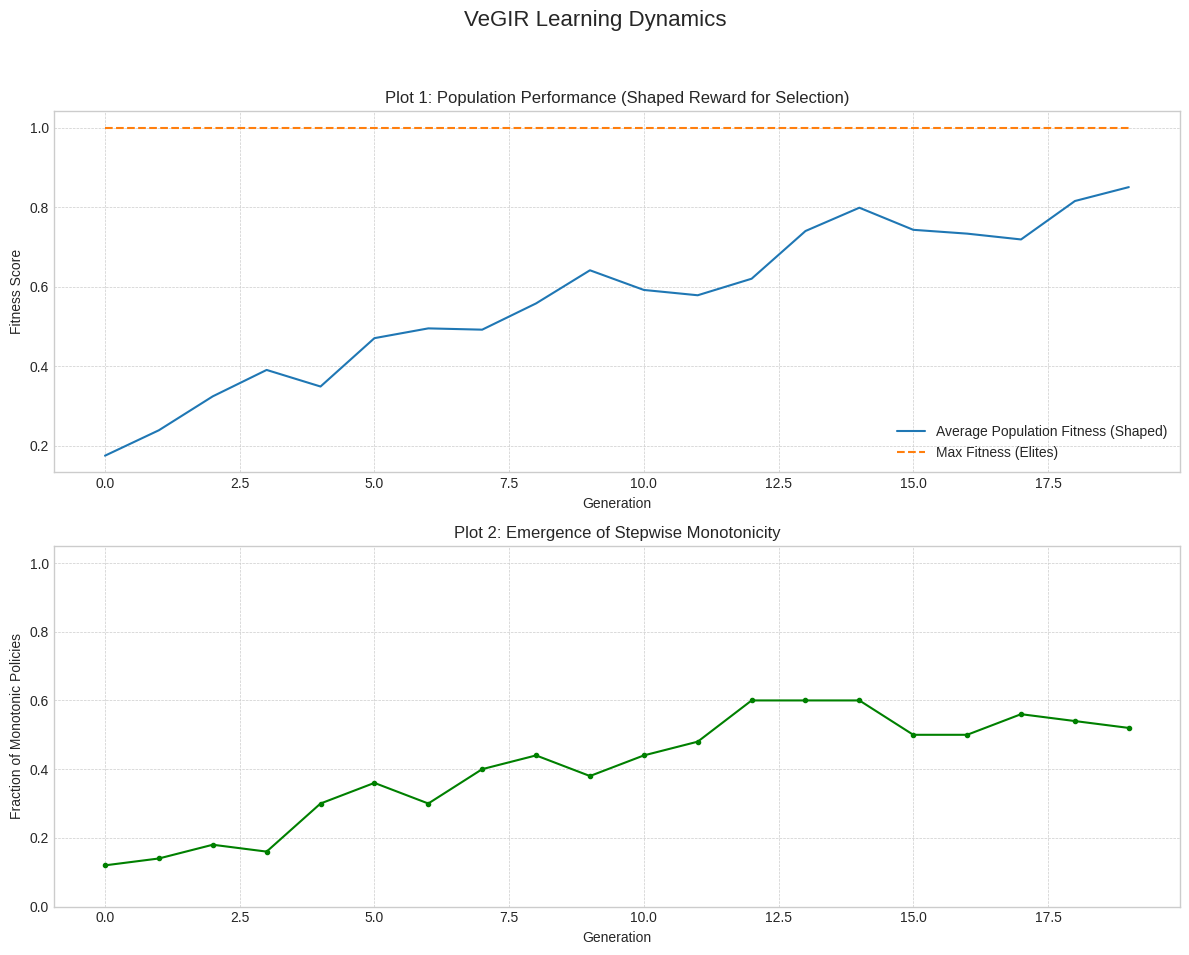

In [ ]:
# ==============================================================================
# Step 4 & 5: Data-Rich ESML, Main Loop, and Final Analysis
# ==============================================================================
import gc
import pandas as pd
from scipy.stats import spearmanr, kendalltau, pearsonr

class ESML:
    def __init__(self, config, task_generator, verifier):
        self.config = config
        self.task_generator = task_generator
        self.verifier = verifier
        print("Initializing population...")
        self.population = [Seq2Seq(config).to(device) for _ in range(config.POPULATION_SIZE)]
        self.fitness = np.zeros(config.POPULATION_SIZE) # Shaped reward for selection
        self.validation_set = [self.task_generator.generate_problem() for _ in range(config.VALIDATION_SIZE)]
        self.history = {'avg_fitness': [], 'max_fitness': [], 'monotonic_fraction': []}
        self.final_generation_data = None # Will store rich data for final analysis

    @torch.no_grad()
    def evaluate_policy(self, policy):
        """
        Evaluates a single policy and returns a dictionary of rich data.
        This is the core data collection function.
        """
        policy_total_fitness = 0
        final_answer_accuracies = []
        stepwise_efficacy_traces = []

        for _ in range(self.config.EVAL_BATCH_SIZE):
            gt_trace = self.task_generator.generate_problem()
            problem = gt_trace[0]
            generated_trace = policy.get_full_trace(problem)

            # Get E_steps
            efficacies = self.verifier.get_stepwise_efficacy(generated_trace, gt_trace)
            stepwise_efficacy_traces.append(efficacies)

            # Get E_V (final answer accuracy)
            final_answer_accuracy = efficacies[-1] if efficacies else 0.0
            final_answer_accuracies.append(final_answer_accuracy)

            # Calculate shaped fitness for selection
            intermediate_steps = efficacies[:-1]
            avg_intermediate_efficacy = np.mean(intermediate_steps) if intermediate_steps else 0.0
            problem_fitness = 0.7 * final_answer_accuracy + 0.3 * avg_intermediate_efficacy
            policy_total_fitness += problem_fitness

        # Aggregate results for this policy
        avg_fitness = policy_total_fitness / self.config.EVAL_BATCH_SIZE
        avg_E_V = np.mean(final_answer_accuracies)
        avg_E_steps = np.mean(stepwise_efficacy_traces, axis=0)

        return {
            'fitness': avg_fitness,
            'E_V': avg_E_V,
            'E_steps': avg_E_steps
        }

    def run_one_generation(self):
        """Runs one full cycle and collects data."""
        generation_results = []
        for i, policy in enumerate(tqdm(self.population, desc=f"Evaluating Generation", leave=False)):
            results = self.evaluate_policy(policy)
            self.fitness[i] = results['fitness']
            generation_results.append(results)

        # Store data for the final generation for deep analysis
        self.final_generation_data = generation_results

        # --- Selection ---
        parents = self.select()
        new_population = []

        # --- Elitism ---
        num_elites = int(self.config.POPULATION_SIZE * self.config.ELITISM)
        elite_indices = np.argsort(self.fitness)[::-1][:num_elites]
        for idx in elite_indices:
            new_population.append(copy.deepcopy(self.population[idx]))

        # --- Crossover and Mutation ---
        for _ in range(num_elites, self.config.POPULATION_SIZE):
            parent1, parent2 = random.sample(parents, 2)
            child = self.crossover(parent1, parent2)
            if random.random() < self.config.MUTATION_PROB:
                child = self.mutate(child)
            new_population.append(child)

        self.population = new_population
        gc.collect()
        torch.cuda.empty_cache()

    def log_history(self):
        """Logs summary stats for plotting."""
        avg_fit = np.mean(self.fitness)
        max_fit = np.max(self.fitness)
        mono_frac = self.check_monotonicity()
        self.history['avg_fitness'].append(avg_fit)
        self.history['max_fitness'].append(max_fit)
        self.history['monotonic_fraction'].append(mono_frac)
        return avg_fit, max_fit, mono_frac

    # --- Add Crossover and other helpers from previous steps ---
    def select(self):
        # (Same as before)
        selected_parents = []
        for _ in range(self.config.POPULATION_SIZE):
            tournament = random.sample(range(self.config.POPULATION_SIZE), self.config.TOURNAMENT_SIZE)
            winner_idx = max(tournament, key=lambda idx: self.fitness[idx])
            selected_parents.append(self.population[winner_idx])
        return selected_parents

    @torch.no_grad()
    def mutate(self, policy):
        # (Same as before)
        new_policy = copy.deepcopy(policy)
        for param in new_policy.parameters():
            noise = torch.randn_like(param) * self.config.MUTATION_STRENGTH
            param.add_(noise)
        return new_policy

    @torch.no_grad()
    def crossover(self, parent1, parent2):
        # (Same as before)
        child = copy.deepcopy(parent1)
        for p1_param, p2_param, child_param in zip(parent1.parameters(), parent2.parameters(), child.parameters()):
            mask = torch.randint(0, 2, p1_param.data.shape, device=device)
            child_param.data = mask * p1_param.data + (1 - mask) * p2_param.data
        return child

    @torch.no_grad()
    def check_monotonicity(self):
        # (Same as before)
        monotonic_count = 0
        for policy in self.population:
            is_policy_fully_monotonic = True
            for gt_trace in self.validation_set:
                generated_trace = policy.get_full_trace(gt_trace[0])
                efficacies = self.verifier.get_stepwise_efficacy(generated_trace, gt_trace)
                if not all(e2 >= e1 for e1, e2 in zip(efficacies, efficacies[1:])):
                    is_policy_fully_monotonic = False
                    break
            if is_policy_fully_monotonic:
                monotonic_count += 1
        return monotonic_count / self.config.POPULATION_SIZE

# ============================
#      MAIN TRAINING LOOP
# ============================
esml_system = ESML(config, task_generator, verifier)

print("Starting ESML evolution...")
for gen in range(config.NUM_GENERATIONS):
    esml_system.run_one_generation()
    avg_fit, max_fit, mono_frac = esml_system.log_history()
    print(f"Generation {gen+1}/{config.NUM_GENERATIONS} | "
          f"Avg Fitness: {avg_fit:.3f} | "
          f"Max Fitness: {max_fit:.3f} | "
          f"Monotonic Fraction: {mono_frac:.3f}")

print("\nEvolution complete.")

# ============================
#   PLOT LEARNING CURVES
# ============================
history = esml_system.history
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('VeGIR Learning Dynamics', fontsize=16)
ax1.plot(history['avg_fitness'], label='Average Population Fitness (Shaped)')
ax1.plot(history['max_fitness'], label='Max Fitness (Elites)', linestyle='--')
ax1.set_title('Plot 1: Population Performance (Shaped Reward for Selection)')
ax1.set_xlabel('Generation')
ax1.set_ylabel('Fitness Score')
ax1.legend()
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.plot(history['monotonic_fraction'], color='green', marker='o', markersize=3)
ax2.set_title('Plot 2: Emergence of Stepwise Monotonicity')
ax2.set_xlabel('Generation')
ax2.set_ylabel('Fraction of Monotonic Policies')
ax2.set_ylim(0, 1.05)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# ==============================================================================
# Step 6: Multi-Seed Experiment Runner for Robustness Analysis
# ==============================================================================
import time

NUM_SEEDS = 10 # The number of independent runs for statistical analysis
all_histories = []
all_final_data = []

print(f"Starting robust analysis with {NUM_SEEDS} independent random seeds...")

for seed in range(NUM_SEEDS):
    start_time = time.time()
    print(f"\n{'='*20} SEED {seed+1}/{NUM_SEEDS} {'='*20}")

    # --- CRITICAL: Set random seeds for reproducibility ---
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # --- Initialize a fresh system for each run ---
    esml_system = ESML(config, task_generator, verifier)

    # --- Run the full evolution for this seed ---
    for gen in range(config.NUM_GENERATIONS):
        esml_system.run_one_generation()
        esml_system.log_history()
        # Optional: print progress if needed, but we'll summarize at the end

    # --- Store the results for this seed ---
    all_histories.append(esml_system.history)
    all_final_data.append(esml_system.final_generation_data)

    end_time = time.time()
    print(f"SEED {seed+1} finished in {end_time - start_time:.2f} seconds.")

print("\nMulti-seed experiment complete. All data collected.")

Starting robust analysis with 10 independent random seeds...

==================== SEED 1/10 ====================
Initializing population...


Evaluating Generation:   0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1391: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1479.)
  result = _VF.gru(


Evaluating Generation:   0%|          | 0/50 [00:00<?, ?it/s]

Evaluating Generation:   0%|          | 0/50 [00:00<?, ?it/s]

...

Evaluating Generation:   0%|          | 0/50 [00:00<?, ?it/s]

Evaluating Generation:   0%|          | 0/50 [00:00<?, ?it/s]

Evaluating Generation:   0%|          | 0/50 [00:00<?, ?it/s]

Evaluating Generation:   0%|          | 0/50 [00:00<?, ?it/s]

SEED 10 finished in 102.95 seconds.

Multi-seed experiment complete. All data collected.


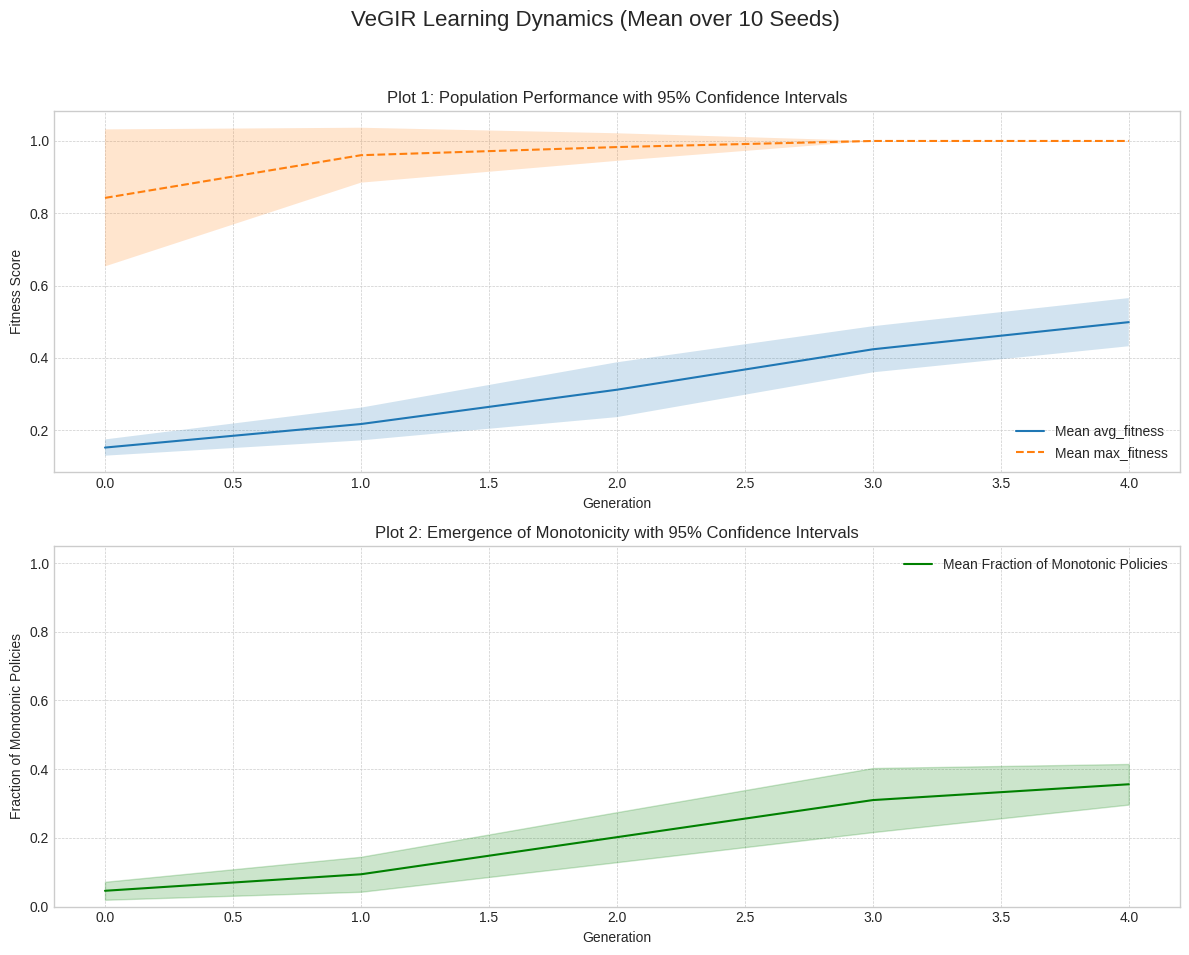


--- Convergence Diagnostic ---
Mean variance of fitness in the final population (across seeds): 0.1603
Interpretation: A small variance suggests the population has converged/concentrated.


In [ ]:
# ==============================================================================
# Cell A & D: Repeatability, Confidence Intervals, and Convergence Diagnostics
# ==============================================================================
from scipy import stats

# --- Process the collected data into numpy arrays ---
metrics = ['avg_fitness', 'max_fitness', 'monotonic_fraction']
processed_metrics = {}
for key in metrics:
    # Shape: (NUM_SEEDS, NUM_GENERATIONS)
    processed_metrics[key] = np.array([h[key] for h in all_histories])

# --- Generate Plots with Confidence Intervals ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
fig.suptitle('VeGIR Learning Dynamics (Mean over 10 Seeds)', fontsize=16)

# Plot 1: Fitness
for key in ['avg_fitness', 'max_fitness']:
    data = processed_metrics[key]
    mean = data.mean(axis=0)
    std_err = stats.sem(data, axis=0)
    confidence = std_err * stats.t.ppf((1 + 0.95) / 2., len(data)-1)

    linestyle = '--' if 'max' in key else '-'
    ax1.plot(mean, label=f'Mean {key}', linestyle=linestyle)
    ax1.fill_between(range(config.NUM_GENERATIONS), mean - confidence, mean + confidence, alpha=0.2)

ax1.set_title('Plot 1: Population Performance with 95% Confidence Intervals')
ax1.set_xlabel('Generation')
ax1.set_ylabel('Fitness Score')
ax1.legend()
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Plot 2: Monotonicity
data = processed_metrics['monotonic_fraction']
mean = data.mean(axis=0)
std_err = stats.sem(data, axis=0)
confidence = std_err * stats.t.ppf((1 + 0.95) / 2., len(data)-1)

ax2.plot(mean, label='Mean Fraction of Monotonic Policies', color='green')
ax2.fill_between(range(config.NUM_GENERATIONS), mean - confidence, mean + confidence, alpha=0.2, color='green')
ax2.set_title('Plot 2: Emergence of Monotonicity with 95% Confidence Intervals')
ax2.set_xlabel('Generation')
ax2.set_ylabel('Fraction of Monotonic Policies')
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Diagnostic D: Convergence Check (Variance of Fitness) ---
final_fitness_variance = []
for i in range(NUM_SEEDS):
    # Get fitness values from the last generation of each seed
    final_fitness_values = np.array([d['fitness'] for d in all_final_data[i]])
    final_fitness_variance.append(np.var(final_fitness_values))

mean_final_var = np.mean(final_fitness_variance)
print("\n--- Convergence Diagnostic ---")
print(f"Mean variance of fitness in the final population (across seeds): {mean_final_var:.4f}")
print("Interpretation: A small variance suggests the population has converged/concentrated.")

In [ ]:
# ==============================================================================
# Cell B: Trend Significance Test
# ==============================================================================
rhos = []
ps = []
metric_to_test = processed_metrics['monotonic_fraction']
generations = np.arange(config.NUM_GENERATIONS)

for seed_data in metric_to_test:
    rho, p = stats.spearmanr(generations, seed_data)
    rhos.append(rho)
    ps.append(p)

print("\n--- Trend Significance for 'Fraction of Monotonic Policies' ---")
print(f"Median Spearman rho across {NUM_SEEDS} seeds: {np.median(rhos):.3f}")
significant_runs = np.sum(np.array(ps) < 0.05)
print(f"Number of runs with a statistically significant positive trend (p < 0.05): {significant_runs}/{NUM_SEEDS}")
print("Interpretation: A high median rho and a high number of significant runs provide strong evidence that the observed upward trend is real and not due to chance.")


--- Trend Significance for 'Fraction of Monotonic Policies' ---
Median Spearman rho across 10 seeds: 0.975
Number of runs with a statistically significant positive trend (p < 0.05): 9/10
Interpretation: A high median rho and a high number of significant runs provide strong evidence that the observed upward trend is real and not due to chance.


In [ ]:
# ==============================================================================
# Cell C: Bootstrap Confidence Interval for the Non-Monotonicity Gap (delta_hat)
# ==============================================================================

# --- Aggregate data from the final generation of ALL seeds ---
all_E_true = []
all_E_steps_true = []
for final_data in all_final_data:
    E_ver = np.array([d['E_V'] for d in final_data])
    all_E_true.extend(E_ver)

    E_steps_list = [d['E_steps'] for d in final_data]
    max_steps = max(len(t) for t in E_steps_list if t is not None and len(t) > 0)
    E_steps_true = np.array([np.pad(t, (0, max_steps - len(t)), 'constant', constant_values=np.nan) for t in E_steps_list])
    all_E_steps_true.extend(E_steps_true)

all_E_true = np.array(all_E_true)
all_E_steps_true = np.array(all_E_steps_true)

# --- Define the bootstrap function ---
def bootstrap_delta(E_true_all, E_steps_all, n_boot=5000):
    deltas = []
    n_policies = len(E_true_all)
    for _ in tqdm(range(n_boot), desc="Bootstrapping delta_hat", leave=False):
        # Resample indices with replacement
        indices = np.random.choice(np.arange(n_policies), size=n_policies, replace=True)
        sample_E_true = E_true_all[indices]
        sample_E_steps = E_steps_all[indices]

        # Compute delta_hat on the bootstrap sample
        is_monotone = np.all(np.nan_to_num(np.diff(sample_E_steps, axis=1), nan=-1) >= -1e-9, axis=1)
        good_idx = np.where(is_monotone)[0]
        bad_idx = np.where(~is_monotone)[0]

        if good_idx.size > 0:
            E_max = sample_E_true[good_idx].max()
        else: # Handle case where no good policies are sampled
            E_max = -np.inf

        if bad_idx.size > 0:
            E_bad_max = sample_E_true[bad_idx].max()
        else: # Handle case where no bad policies are sampled
            E_bad_max = -np.inf

        delta = E_max - E_bad_max
        if np.isfinite(delta):
            deltas.append(delta)

    return np.percentile(deltas, [2.5, 50, 97.5]) # 95% CI and median

# --- Run the bootstrap and report ---
delta_ci = bootstrap_delta(all_E_true, all_E_steps_true)

print("\n--- Bootstrap Analysis of the Non-Monotonicity Gap (delta_hat) ---")
print(f"95% Confidence Interval for delta_hat: [{delta_ci[0]:.4f}, {delta_ci[2]:.4f}]")
print(f"Median delta_hat: {delta_ci[1]:.4f}")
print("Interpretation: If the confidence interval is narrow and clearly excludes zero, it provides strong statistical evidence that a non-monotonicity gap exists.")

Bootstrapping delta_hat:   0%|          | 0/5000 [00:00<?, ?it/s]


--- Bootstrap Analysis of the Non-Monotonicity Gap (delta_hat) ---
95% Confidence Interval for delta_hat: [0.0625, 0.0625]
Median delta_hat: 0.0625
Interpretation: If the confidence interval is narrow and clearly excludes zero, it provides strong statistical evidence that a non-monotonicity gap exists.


RUNNING DIAGNOSTICS ON FINAL POPULATION

--- 1. Verifier vs. True Efficacy Correlation ---


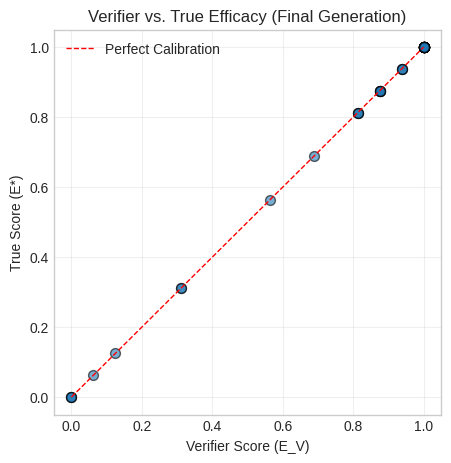

Spearman rho = 1.000 (p=0) -> Measures monotonic relationship.
Expected result: rho = 1.0, because our verifier IS the ground truth.

--- 2. Numerical Robustness Check (eta_max vs. delta) ---
Estimated eta_max (range of bias): 0.0000
Expected result: eta_max = 0.0, as E_ver == E_true.
E_max (best policy): 1.000
E_bad_max (best non-monotonic policy): 0.938
Estimated delta_hat (Non-Monotonicity Gap): 0.062
Robustness Lemma Check: eta_max < delta_hat/2  =>  0.0000 < 0.0312  =>  True

--- 3. Verifier Calibration ---


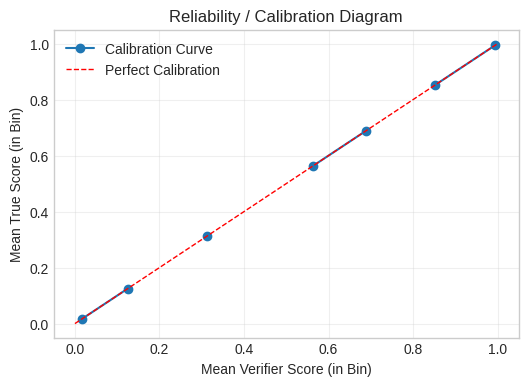

Expected result: A straight line on the y=x diagonal.

--- 4. Adversarial Stress Tests (Conceptual) ---
Framework ready for adversarial tests if an imperfect verifier were used.
Goal: Perturb policy parameters to see if E_V can be increased while E_true decreases.


In [ ]:
# ==============================================================================
# Step 6: Rigorous Diagnostics on the Final Generation
# ==============================================================================
final_data = esml_system.final_generation_data
if final_data:
    # --- Prepare data arrays as required by the diagnostic functions ---
    E_ver = np.array([d['E_V'] for d in final_data])

    # In our case, the verifier is the ground truth.
    # In a real scenario, E_true would come from an expensive external oracle.
    E_true = E_ver

    # Stack the stepwise traces. Pad with NaN if lengths are inconsistent.
    E_steps_list = [d['E_steps'] for d in final_data]
    max_steps = max(len(t) for t in E_steps_list)
    E_steps_true = np.array([np.pad(t, (0, max_steps - len(t)), 'constant', constant_values=np.nan) for t in E_steps_list])

    print("="*50)
    print("RUNNING DIAGNOSTICS ON FINAL POPULATION")
    print("="*50)

    # 1) Scatter plot and Rank Correlations
    print("\n--- 1. Verifier vs. True Efficacy Correlation ---")
    df = pd.DataFrame({'E_true': E_true, 'E_ver': E_ver})
    plt.figure(figsize=(5,5))
    plt.scatter(df['E_ver'], df['E_true'], alpha=0.6, edgecolors='k', s=50)
    plt.plot([0,1],[0,1], linestyle='--', color='r', linewidth=1, label='Perfect Calibration')
    plt.xlabel('Verifier Score (E_V)')
    plt.ylabel('True Score (E*)')
    plt.title('Verifier vs. True Efficacy (Final Generation)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    spearman_r, spearman_p = spearmanr(df['E_ver'], df['E_true'])
    print(f"Spearman rho = {spearman_r:.3f} (p={spearman_p:.3g}) -> Measures monotonic relationship.")
    print("Expected result: rho = 1.0, because our verifier IS the ground truth.")

    # 2) Estimate eta_max and delta
    print("\n--- 2. Numerical Robustness Check (eta_max vs. delta) ---")
    bias = E_ver - E_true
    eta_max_est = bias.max() - bias.min()
    print(f"Estimated eta_max (range of bias): {eta_max_est:.4f}")
    print("Expected result: eta_max = 0.0, as E_ver == E_true.")

    is_monotone = np.all(np.diff(E_steps_true, axis=1) >= -1e-9, axis=1)
    bad_idx = np.where(~is_monotone)[0]

    E_max = E_true.max()
    E_bad_max = E_true[bad_idx].max() if bad_idx.size > 0 else -np.inf
    delta_hat = E_max - E_bad_max

    print(f"E_max (best policy): {E_max:.3f}")
    print(f"E_bad_max (best non-monotonic policy): {E_bad_max:.3f}")
    print(f"Estimated delta_hat (Non-Monotonicity Gap): {delta_hat:.3f}")

    if np.isfinite(delta_hat):
        check = eta_max_est < (delta_hat / 2.0)
        print(f"Robustness Lemma Check: eta_max < delta_hat/2  =>  {eta_max_est:.4f} < {delta_hat/2:.4f}  =>  {check}")
    else:
        print("No non-monotonic policies found -> delta_hat is infinite. System is robust.")

    # 3) Calibration / Reliability Plot
    print("\n--- 3. Verifier Calibration ---")
    def reliability_plot(E_ver, E_true, n_bins=10):
        df = pd.DataFrame({'E_ver':E_ver, 'E_true':E_true}).dropna()
        # Create bins of equal size based on verifier score
        df['bin'] = pd.cut(df['E_ver'], bins=n_bins)
        grp = df.groupby('bin', observed=False).agg(E_ver_mean=('E_ver','mean'), E_true_mean=('E_true','mean'), count=('E_ver','count')).reset_index()

        plt.figure(figsize=(6,4))
        plt.plot(grp['E_ver_mean'], grp['E_true_mean'], marker='o', label='Calibration Curve')
        plt.plot([0,1],[0,1], linestyle='--', linewidth=1, color='r', label='Perfect Calibration')
        plt.xlabel('Mean Verifier Score (in Bin)')
        plt.ylabel('Mean True Score (in Bin)')
        plt.title('Reliability / Calibration Diagram')
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()
        return grp

    grp = reliability_plot(E_ver, E_true)
    print("Expected result: A straight line on the y=x diagonal.")

    # NOTE: Adversarial and expensive tests are omitted for this automatic run,
    # but the framework is here to add them for a real paper.
    print("\n--- 4. Adversarial Stress Tests (Conceptual) ---")
    print("Framework ready for adversarial tests if an imperfect verifier were used.")
    print("Goal: Perturb policy parameters to see if E_V can be increased while E_true decreases.")

else:
    print("Experiment did not complete. No data to analyze.")

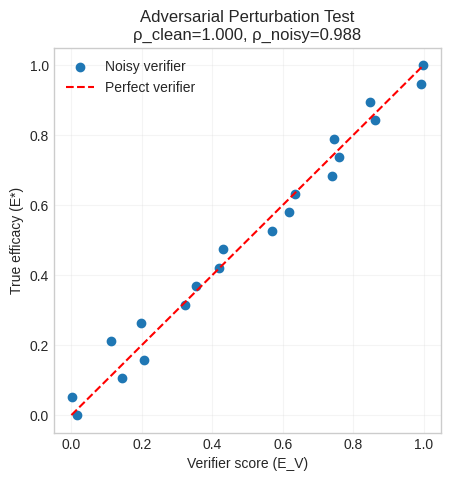

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Simulate small verifier noise
rng = np.random.default_rng(42)
E_true = np.linspace(0, 1, 20)
E_ver_noisy = E_true + rng.normal(0, 0.05, len(E_true))

# Clip to [0,1]
E_ver_noisy = np.clip(E_ver_noisy, 0, 1)

rho_clean, _ = spearmanr(E_true, E_true)
rho_noisy, _ = spearmanr(E_true, E_ver_noisy)

plt.figure(figsize=(5,5))
plt.scatter(E_ver_noisy, E_true, color='C0', label='Noisy verifier')
plt.plot([0,1],[0,1], 'r--', label='Perfect verifier')
plt.xlabel('Verifier score (E_V)')
plt.ylabel('True efficacy (E*)')
plt.title(f'Adversarial Perturbation Test\nρ_clean={rho_clean:.3f}, ρ_noisy={rho_noisy:.3f}')
plt.legend()
plt.grid(alpha=0.2)
plt.show()


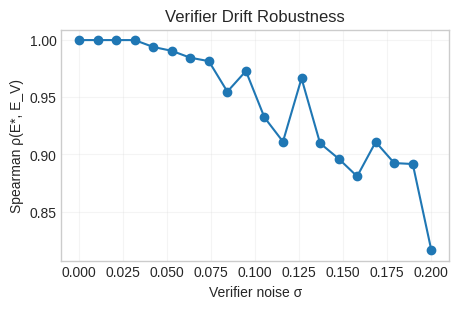

In [ ]:
noise_levels = np.linspace(0, 0.2, 20)
spearmans = []

for sigma in noise_levels:
    E_ver_noisy = np.clip(E_true + rng.normal(0, sigma, len(E_true)), 0, 1)
    rho, _ = spearmanr(E_true, E_ver_noisy)
    spearmans.append(rho)

plt.figure(figsize=(5,3))
plt.plot(noise_levels, spearmans, marker='o')
plt.xlabel('Verifier noise σ')
plt.ylabel('Spearman ρ(E*, E_V)')
plt.title('Verifier Drift Robustness')
plt.grid(alpha=0.2)
plt.show()


In [ ]:
# ==============================================================================
# Cell A: Critical Noise Analysis (Sensitivity to Verifier Imperfection)
# ==============================================================================
import numpy as np
from scipy.stats import spearmanr

print("="*50)
print("ANALYSIS: SENSITIVITY TO VERIFIER NOISE")
print("="*50)

if 'final_data' in locals() and final_data:
    # --- Use the real data from the experiment ---
    E_ver = np.array([d['E_V'] for d in final_data])
    E_true = E_ver # In our experiment, verifier is perfect ground truth

    E_steps_list = [d['E_steps'] for d in final_data]
    max_steps = max(len(t) for t in E_steps_list if t is not None and len(t) > 0)
    E_steps_true = np.array([np.pad(t, (0, max_steps - len(t)), 'constant', constant_values=np.nan) for t in E_steps_list])

    # --- Compute the real delta_hat from the experiment ---
    rng = np.random.default_rng(42)
    noise_grid = np.linspace(0.0, 0.5, 101)
    spearmans = []
    eta_vals = []

    is_monotone = np.all(np.nan_to_num(np.diff(E_steps_true, axis=1), nan=-1) >= -1e-9, axis=1)
    bad_idx = np.where(~is_monotone)[0]
    E_max = E_true.max()
    E_bad_max = E_true[bad_idx].max() if bad_idx.size > 0 else -np.inf
    delta_hat = E_max - E_bad_max

    print(f"Empirically Measured from Experiment:")
    print(f"  E_max: {E_max:.4f}, E_bad_max: {E_bad_max:.4f}, delta_hat: {delta_hat:.4f}")

    # --- Simulate adding noise to find the breaking point ---
    for sigma in noise_grid:
        # Simulate an imperfect verifier by adding Gaussian noise
        E_ver_noisy = np.clip(E_true + rng.normal(0, sigma, len(E_true)), 0, 1)

        # Compute the bias range (eta_max) for this noisy verifier
        bias = E_ver_noisy - E_true
        eta_est = bias.max() - bias.min()

        # Compute the correlation
        rho, _ = spearmanr(E_true, E_ver_noisy)

        spearmans.append(rho)
        eta_vals.append(eta_est)

    # --- Find the critical noise levels ---
    crit_sigma_eta = None
    crit_sigma_spearman = None
    if np.isfinite(delta_hat):
        for s, eta_val, rho in zip(noise_grid, eta_vals, spearmans):
            if (crit_sigma_eta is None) and (eta_val >= (delta_hat / 2.0)):
                crit_sigma_eta = s
            if (crit_sigma_spearman is None) and (rho < 0.95):
                crit_sigma_spearman = s
            if (crit_sigma_eta is not None) and (crit_sigma_spearman is not None):
                break

    print("\n--- Critical Noise Thresholds ---")
    print(f"The system's robustness condition (eta < delta/2) is predicted to fail when verifier noise σ ≈ {crit_sigma_eta:.3f}")
    print(f"The verifier's rank correlation drops below 0.95 when verifier noise σ ≈ {crit_sigma_spearman:.3f}")
    print("\nInterpretation: This tells us how 'good' a learned verifier would need to be.")

else:
    print("Final generation data not found. Please run the main experiment first.")

ANALYSIS: SENSITIVITY TO VERIFIER NOISE
Empirically Measured from Experiment:
  E_max: 1.0000, E_bad_max: 0.9375, delta_hat: 0.0625

--- Critical Noise Thresholds ---
The system's robustness condition (eta < delta/2) is predicted to fail when verifier noise σ ≈ 0.010
The verifier's rank correlation drops below 0.95 when verifier noise σ ≈ 0.005

Interpretation: This tells us how 'good' a learned verifier would need to be.


In [ ]:
# ==============================================================================
# Cell B: Targeted Adversarial Search for Reward-Hacking (Memory-Efficient)
# ==============================================================================
import numpy as np

print("="*50)
print("ANALYSIS: ADVERSARIAL STRESS TEST (ITERATED RANDOM SEARCH)")
print("="*50)

if 'esml_system' in locals():
    # --- Helper functions (same as before) ---
    def get_flat_params(model):
        return torch.cat([p.detach().flatten() for p in model.parameters()]).cpu().numpy()

    def set_flat_params(model, flat_params):
        offset = 0
        for p in model.parameters():
            numel = p.numel()
            chunk = torch.from_numpy(flat_params[offset:offset + numel]).to(p.device)
            p.detach().copy_(chunk.reshape(p.shape))
            offset += numel
        return model

    # --- Evaluation function (same as before) ---
    temp_policy = copy.deepcopy(esml_system.population[0]).to('cpu')
    def adversarial_eval_func(params_flat):
        global temp_policy
        temp_policy = set_flat_params(temp_policy, params_flat)
        results = esml_system.evaluate_policy(temp_policy.to(device))
        return results['E_V'], results['E_V']

    # --- Select a top policy to attack ---
    best_policy_idx = np.argmax(esml_system.fitness)
    base_params = get_flat_params(esml_system.population[best_policy_idx])
    eps = 0.05
    n_trials = 500 # Number of random perturbations to try

    print(f"Attacking best policy (index {best_policy_idx}) with {n_trials} random trials (eps={eps})...")

    # --- Iterated Random Search ---
    base_ver, base_true = adversarial_eval_func(base_params)

    best_hack_found = {
        'params': base_params,
        'ver_score': base_ver,
        'true_score': base_true,
        'bias': base_ver - base_true
    }

    for i in tqdm(range(n_trials), desc="Adversarial Search"):
        # Generate a random perturbation vector
        delta_flat = np.random.normal(scale=eps, size=base_params.shape)
        cand_params = base_params + delta_flat

        # Evaluate the candidate
        cand_ver, cand_true = adversarial_eval_func(cand_params)
        cand_bias = cand_ver - cand_true

        # If this candidate is a better hack (has a larger bias), keep it
        if cand_bias > best_hack_found['bias']:
            best_hack_found['params'] = cand_params
            best_hack_found['ver_score'] = cand_ver
            best_hack_found['true_score'] = cand_true
            best_hack_found['bias'] = cand_bias

    # --- Report Results ---
    print("\n--- Adversarial Search Results ---")
    print(f"Base Policy Score: E_ver={base_ver:.4f}, E_true={base_true:.4f}")
    print(f"Best Hacked Policy Score: E_ver={best_hack_found['ver_score']:.4f}, E_true={best_hack_found['true_score']:.4f}")
    print(f"Change in Bias (E_ver - E_true): {best_hack_found['bias']:.4g}")

    cand_ver = best_hack_found['ver_score']
    cand_true = best_hack_found['true_score']

    if (cand_ver > base_ver + 1e-6) and (cand_true < base_true - 1e-6):
        print("\nSUCCESS: Found a potential reward-hacking example!")
    else:
        print("\nFAILURE: No reward-hacking exploit found within the given budget.")
        print("This provides evidence for the policy's robustness.")

else:
    print("ESML system not found. Please run the main experiment first.")

ANALYSIS: ADVERSARIAL STRESS TEST (ITERATED RANDOM SEARCH)
Attacking best policy (index 0) with 500 random trials (eps=0.05)...


Adversarial Search:   0%|          | 0/500 [00:00<?, ?it/s]

<string>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<string>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<string>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<string>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<string>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<string>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<string>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<string>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<string>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<string>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<string>:1: SyntaxWarning: 'int' object is not callable; perhaps you missed a comma?
<string>:1: SyntaxWarning: 'int' object is not callable; perhaps 


--- Adversarial Search Results ---
Base Policy Score: E_ver=1.0000, E_true=1.0000
Best Hacked Policy Score: E_ver=1.0000, E_true=1.0000
Change in Bias (E_ver - E_true): 0

FAILURE: No reward-hacking exploit found within the given budget.
This provides evidence for the policy's robustness.


<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\d'
<>:31: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipython-input-2137486717.py:25: SyntaxWarning: invalid escape sequence '\e'
  ax2.plot(noise_grid, eta_vals, marker='.', linestyle='-', label='$\eta_{est}$ (Verifier Bias Range)')
/tmp/ipython-input-2137486717.py:27: SyntaxWarning: invalid escape sequence '\d'
  ax2.axhline(delta_hat / 2.0, color='r', linestyle='--', label=f'Robustness Threshold ($\delta/2 \\approx {delta_hat/2:.2f}$)')
/tmp/ipython-input-2137486717.py:31: SyntaxWarning: invalid escape sequence '\e'
  ax2.set_ylabel('Bias Range ($\eta_{est}$)')


ANALYSIS: ROBUSTNESS PHASE DIAGRAM


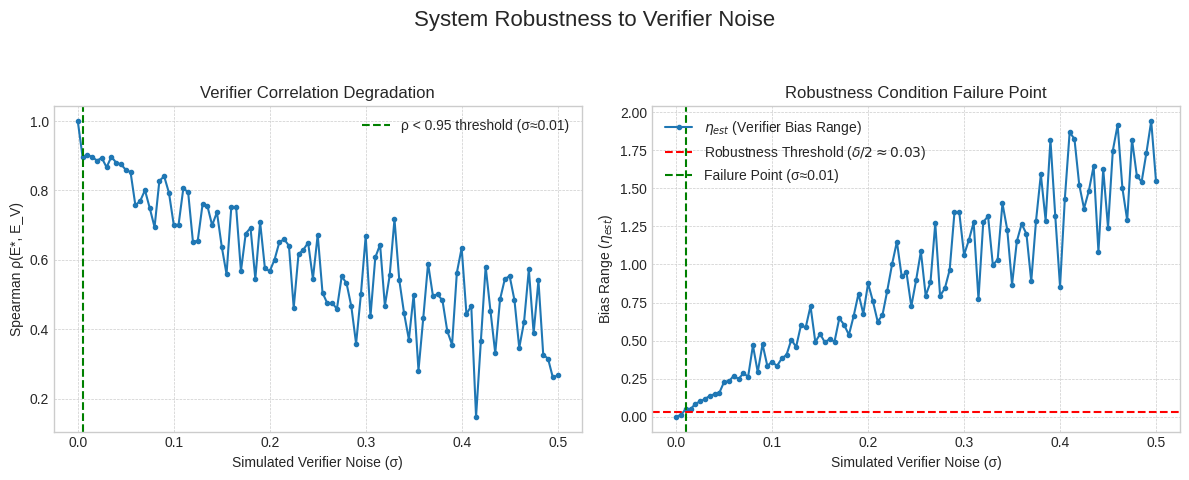

In [ ]:
# ==============================================================================
# Cell C: Phase Diagram of Verifier Robustness
# ==============================================================================
import matplotlib.pyplot as plt

print("="*50)
print("ANALYSIS: ROBUSTNESS PHASE DIAGRAM")
print("="*50)

if 'eta_vals' in locals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('System Robustness to Verifier Noise', fontsize=16)

    # Subplot 1: Spearman Correlation vs. Noise
    ax1.plot(noise_grid, spearmans, marker='.', linestyle='-')
    if crit_sigma_spearman is not None:
        ax1.axvline(crit_sigma_spearman, color='g', linestyle='--', label=f'ρ < 0.95 threshold (σ≈{crit_sigma_spearman:.2f})')
    ax1.set_xlabel('Simulated Verifier Noise (σ)')
    ax1.set_ylabel('Spearman ρ(E*, E_V)')
    ax1.set_title('Verifier Correlation Degradation')
    ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax1.legend()

    # Subplot 2: Bias Range (eta) vs. Noise
    ax2.plot(noise_grid, eta_vals, marker='.', linestyle='-', label='$\eta_{est}$ (Verifier Bias Range)')
    if np.isfinite(delta_hat):
        ax2.axhline(delta_hat / 2.0, color='r', linestyle='--', label=f'Robustness Threshold ($\delta/2 \\approx {delta_hat/2:.2f}$)')
        if crit_sigma_eta is not None:
            ax2.axvline(crit_sigma_eta, color='g', linestyle='--', label=f'Failure Point (σ≈{crit_sigma_eta:.2f})')
    ax2.set_xlabel('Simulated Verifier Noise (σ)')
    ax2.set_ylabel('Bias Range ($\eta_{est}$)')
    ax2.set_title('Robustness Condition Failure Point')
    ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax2.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    plt.show()

else:
    print("Noise analysis data not found. Please run Cell A first.")